In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 0) Config

In [ ]:
DATA_PATH = "/content/bank-additional-full.csv"
EDA_OUTPUT_DIR = "/content/marketing_eda"

os.makedirs(EDA_OUTPUT_DIR, exist_ok=True)

TARGET = "y"

plt.rcParams.update({
    "font.size": 9
})

# 1) Load data

In [ ]:
df = pd.read_csv(DATA_PATH, sep=";")

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# 2) Print

In [ ]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nTarget distribution:")
print(df[TARGET].value_counts(dropna=False))

print("\nMissing values:")
print(df.isnull().sum())



Shape:
(41188, 21)

Columns:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Target distribution:
y
no     36548
yes     4640
Name: count, dtype: int64

Missing values:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


# 3) Summery

In [ ]:
dataset_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_values": df.isnull().sum().values,
    "missing_share": (df.isnull().mean() * 100).values,
    "n_unique": df.nunique().values,
})

dataset_summary.to_csv(
    os.path.join(EDA_OUTPUT_DIR, "dataset_summary.csv"),
    index=False,
)

# 4) Target distribution

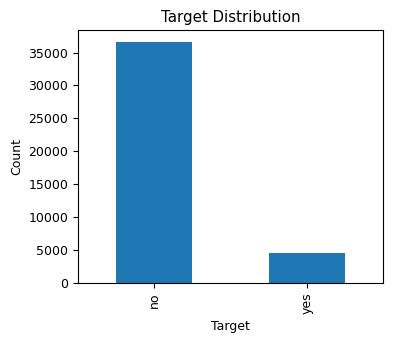

In [ ]:
target_counts = df[TARGET].value_counts()

plt.figure(figsize=(4, 3.5))
target_counts.plot(kind="bar")

plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    os.path.join(EDA_OUTPUT_DIR, "target_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

# 5) Numerical summary

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

numeric_summary = df[numeric_cols].describe().T

numeric_summary.to_csv(
    os.path.join(EDA_OUTPUT_DIR, "numeric_summary.csv")
)

# 6) Histograms for numerical variables

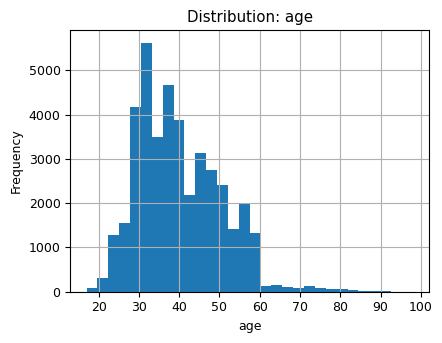

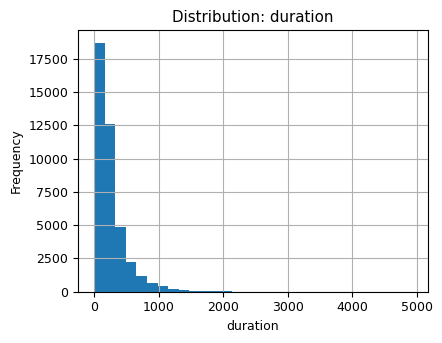

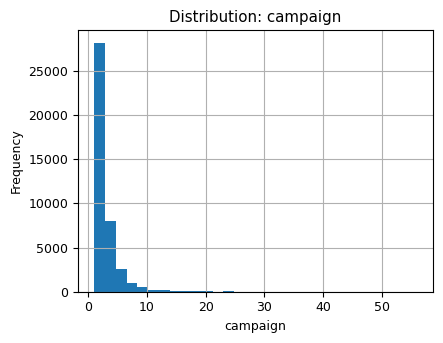

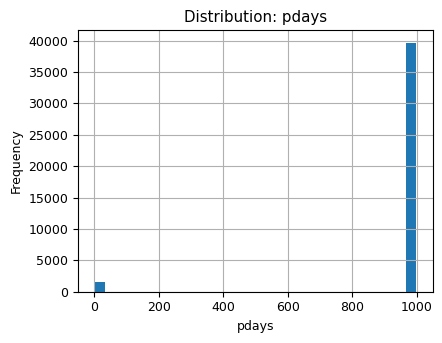

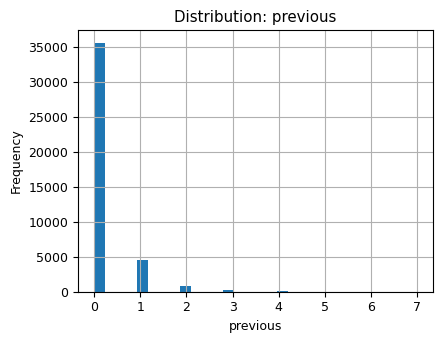

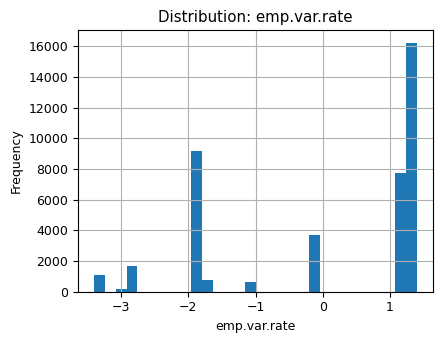

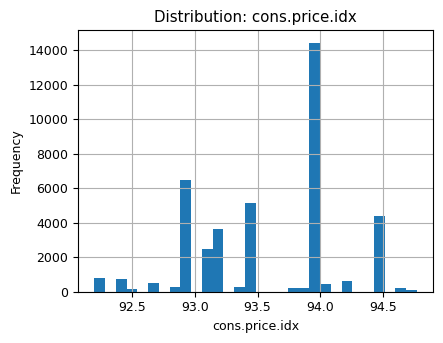

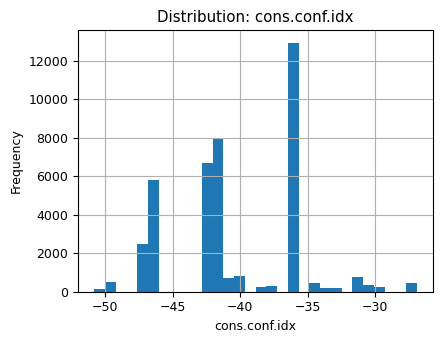

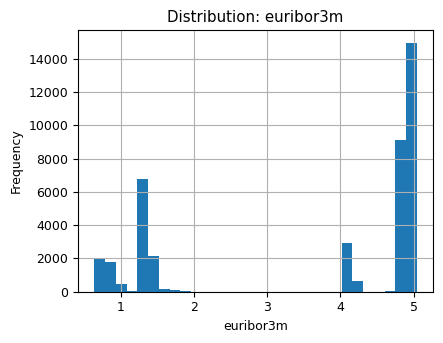

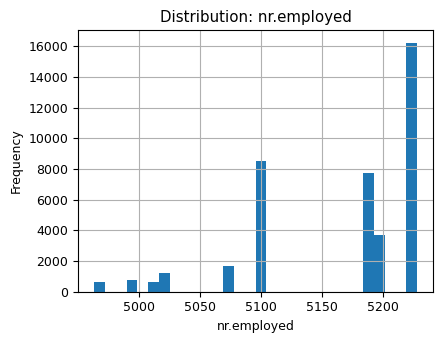

In [ ]:
for col in numeric_cols:

    plt.figure(figsize=(4.5, 3.5))

    df[col].hist(bins=30)

    plt.title(f"Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()

    plt.savefig(
        os.path.join(EDA_OUTPUT_DIR, f"hist_{col}.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    plt.close()

# 7) Correlation matrix

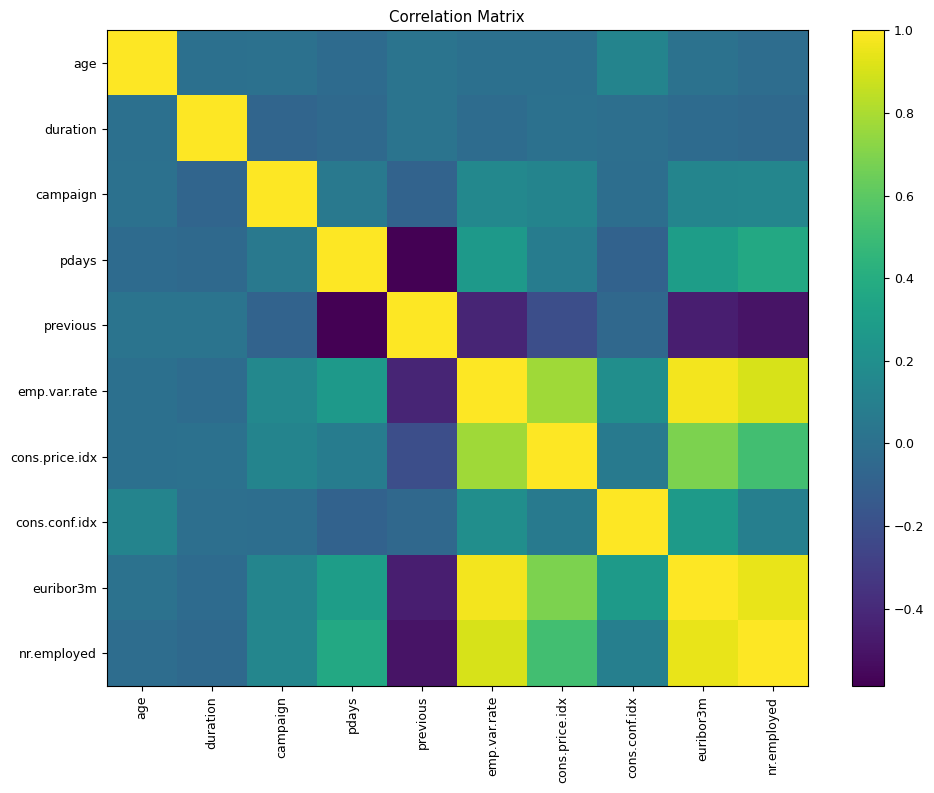

In [ ]:
corr_matrix = df[numeric_cols].corr()

corr_matrix.to_csv(
    os.path.join(EDA_OUTPUT_DIR, "correlation_matrix.csv")
)

plt.figure(figsize=(10, 8))

im = plt.imshow(corr_matrix, aspect="auto")

plt.colorbar(im)

plt.xticks(
    range(len(numeric_cols)),
    numeric_cols,
    rotation=90
)

plt.yticks(
    range(len(numeric_cols)),
    numeric_cols
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    os.path.join(EDA_OUTPUT_DIR, "correlation_matrix.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# 8)  Categorical feature analysis

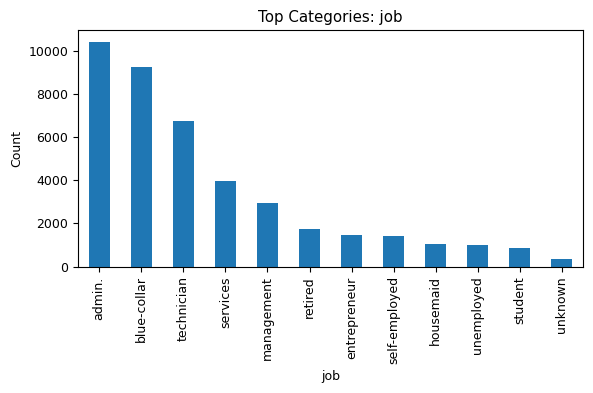

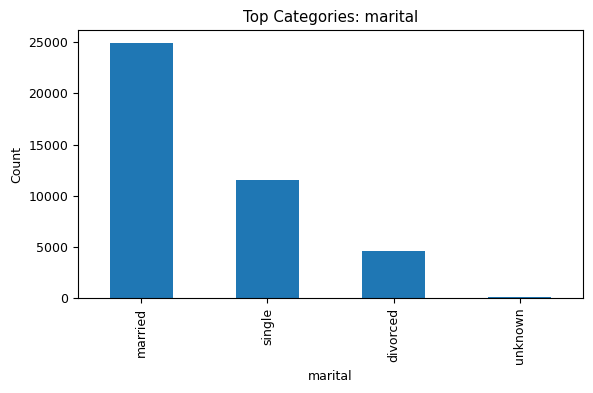

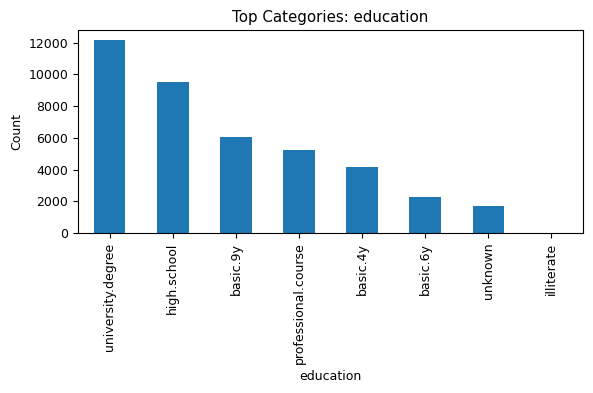

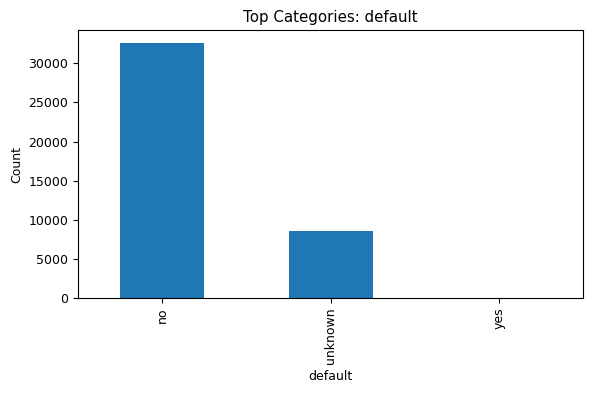

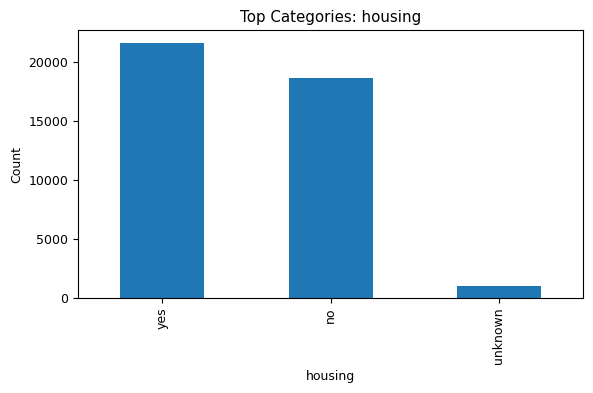

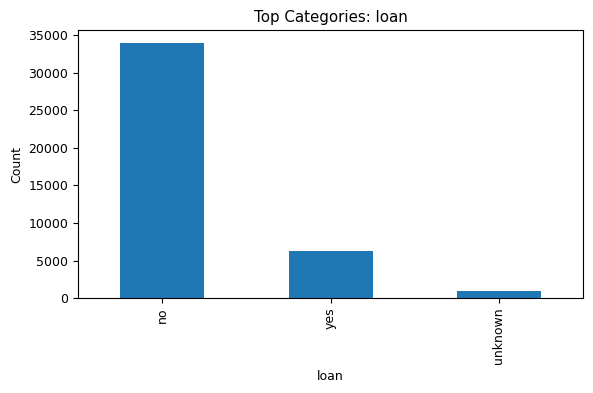

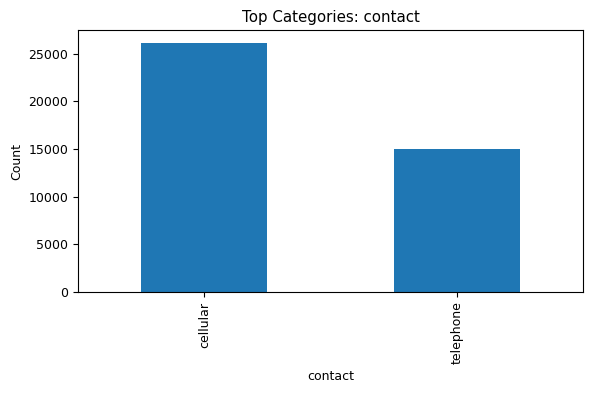

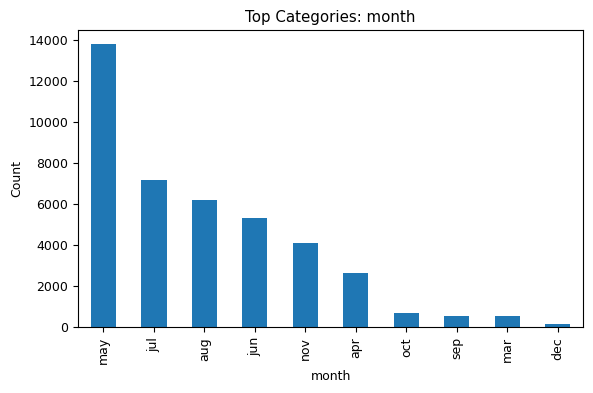

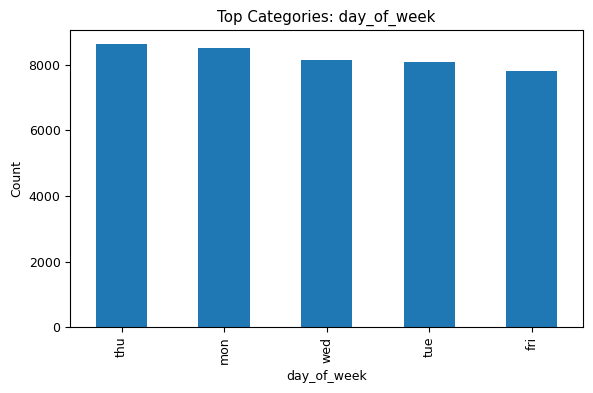

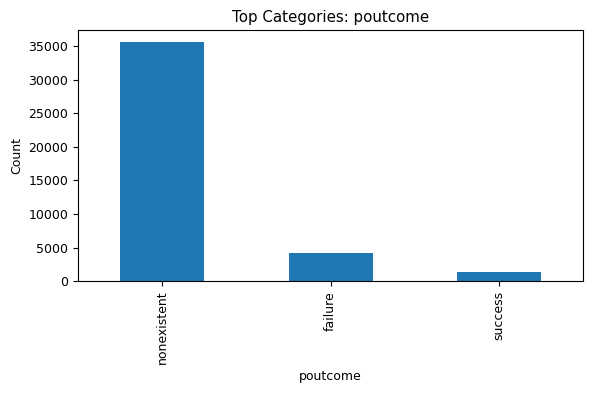

In [ ]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()

if TARGET in categorical_cols:
    categorical_cols.remove(TARGET)

for col in categorical_cols:

    value_counts = df[col].value_counts(dropna=False)

    value_counts.to_csv(
        os.path.join(EDA_OUTPUT_DIR, f"cat_counts_{col}.csv")
    )

    plt.figure(figsize=(6, 4))

    value_counts.head(15).plot(kind="bar")

    plt.title(f"Top Categories: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.tight_layout()

    plt.savefig(
        os.path.join(EDA_OUTPUT_DIR, f"cat_{col}.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    plt.close()

# 9) Target rate by categorical feature

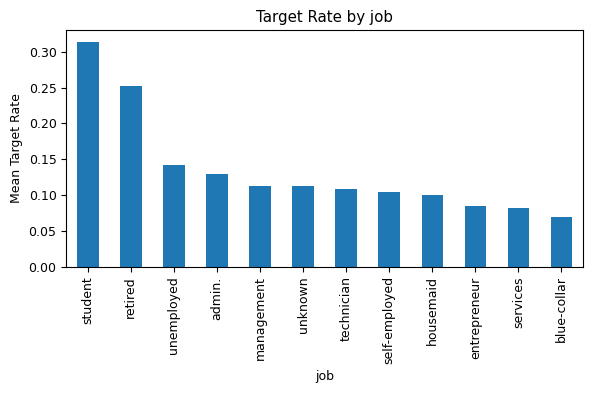

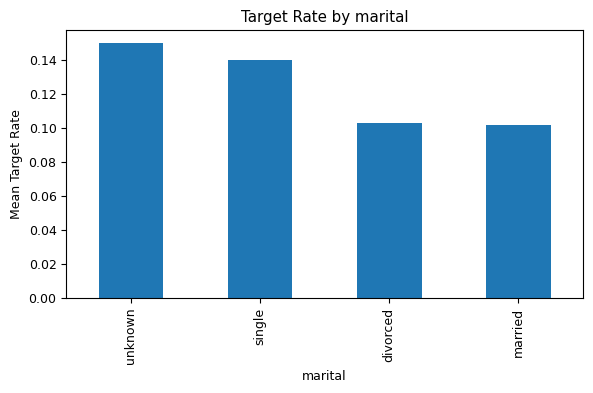

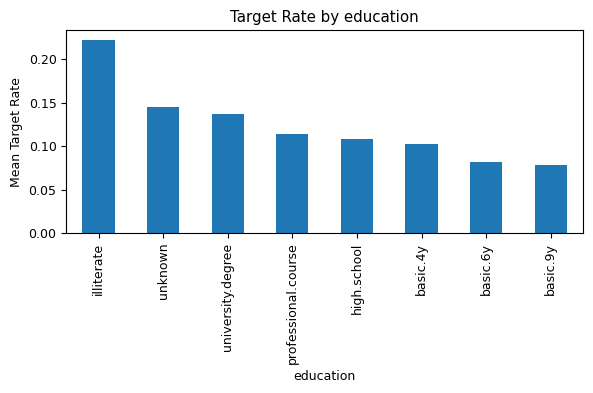

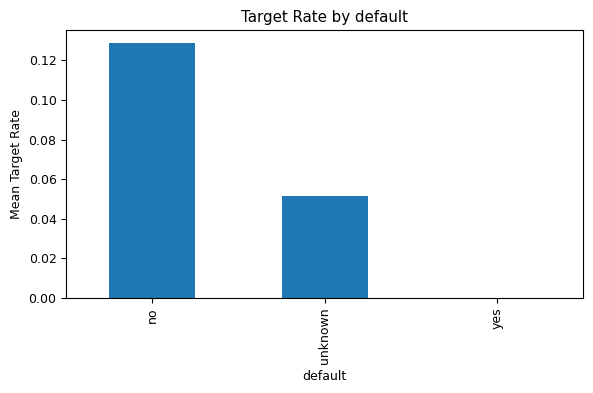

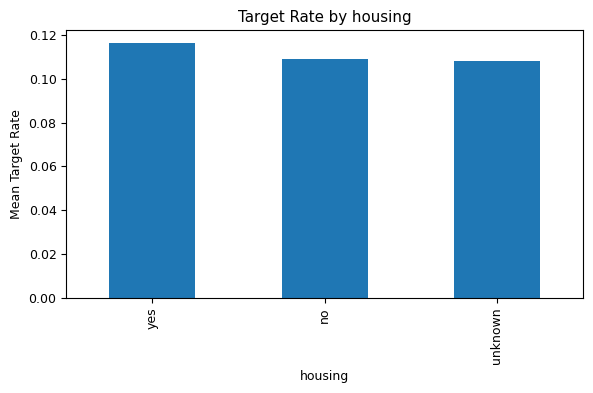

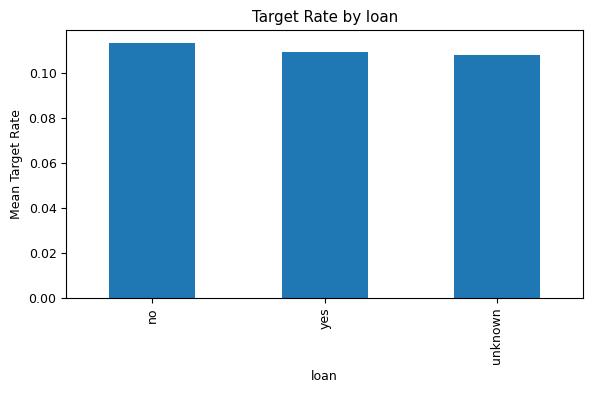

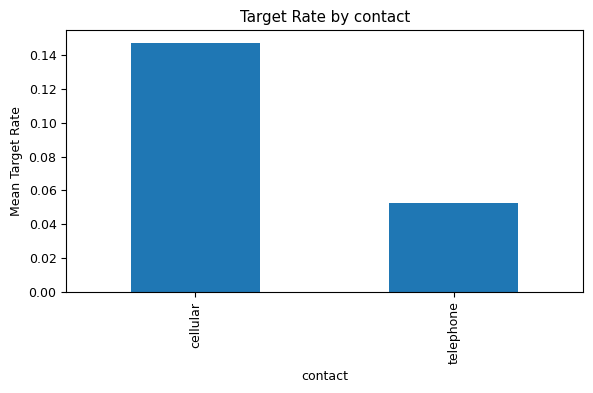

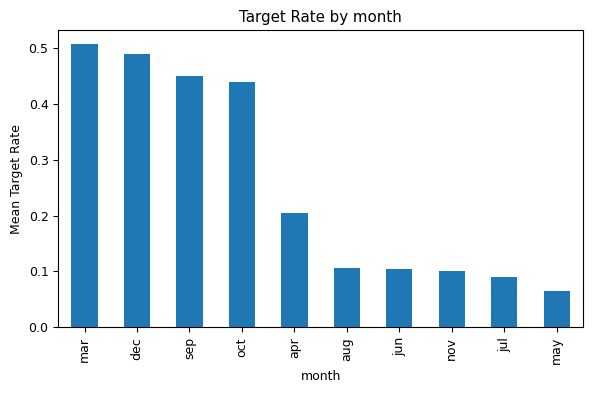

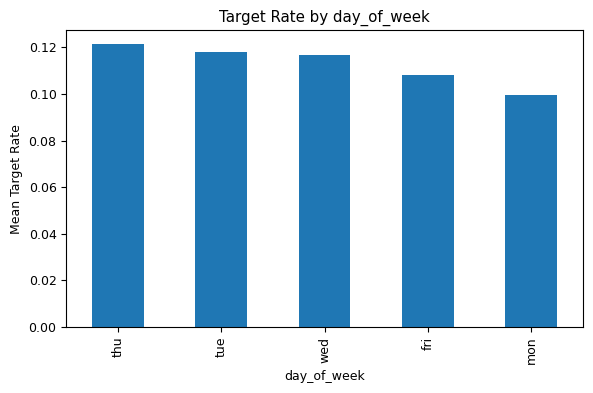

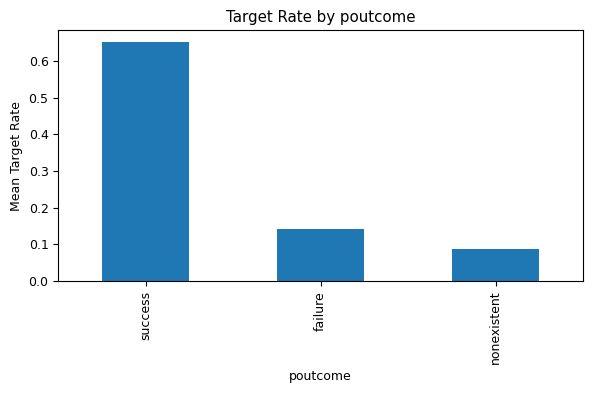

In [ ]:
df_target = df.copy()

df_target[TARGET] = (
    df_target[TARGET]
    .map({"yes": 1, "no": 0})
)

for col in categorical_cols:

    grouped = (
        df_target
        .groupby(col)[TARGET]
        .mean()
        .sort_values(ascending=False)
    )

    grouped.to_csv(
        os.path.join(EDA_OUTPUT_DIR, f"target_rate_{col}.csv")
    )

    plt.figure(figsize=(6, 4))

    grouped.plot(kind="bar")

    plt.title(f"Target Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Mean Target Rate")

    plt.tight_layout()

    plt.savefig(
        os.path.join(EDA_OUTPUT_DIR, f"target_rate_{col}.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    plt.close()


# 10) Class imbalance

In [ ]:
target_rate = df_target[TARGET].mean()

imbalance_summary = pd.DataFrame({
    "metric": [
        "n_rows",
        "n_columns",
        "positive_class_share",
        "negative_class_share",
    ],
    "value": [
        len(df),
        df.shape[1],
        target_rate,
        1 - target_rate,
    ]
})

imbalance_summary.to_csv(
    os.path.join(EDA_OUTPUT_DIR, "imbalance_summary.csv"),
    index=False,
)

# 11) Boxplot

<Figure size 500x400 with 0 Axes>

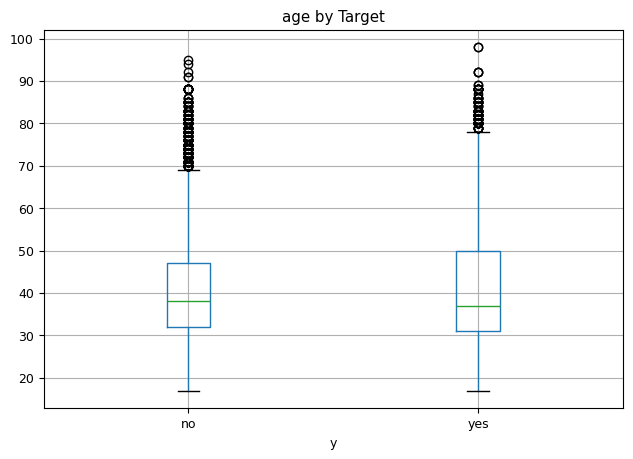

<Figure size 500x400 with 0 Axes>

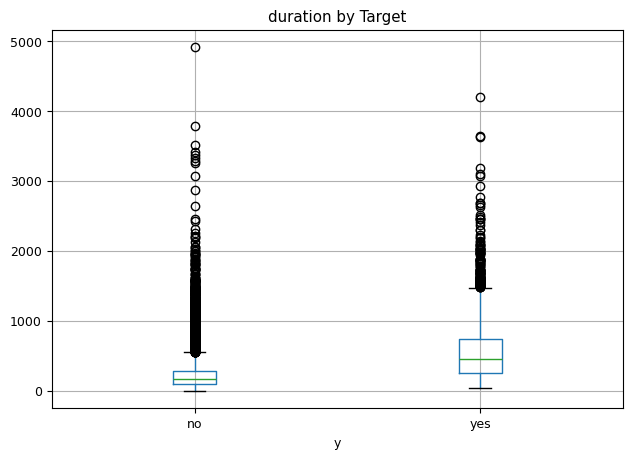

<Figure size 500x400 with 0 Axes>

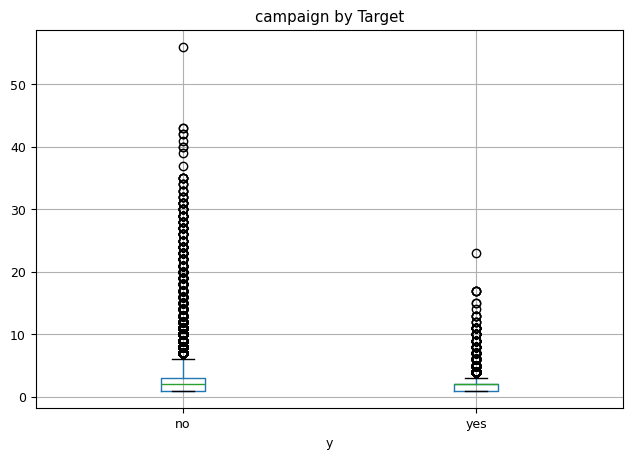

<Figure size 500x400 with 0 Axes>

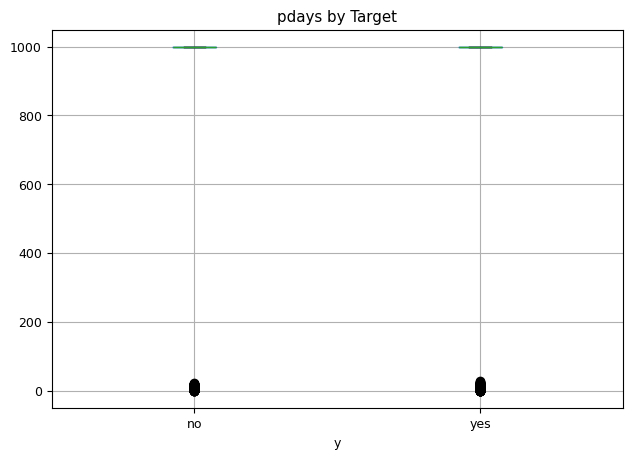

<Figure size 500x400 with 0 Axes>

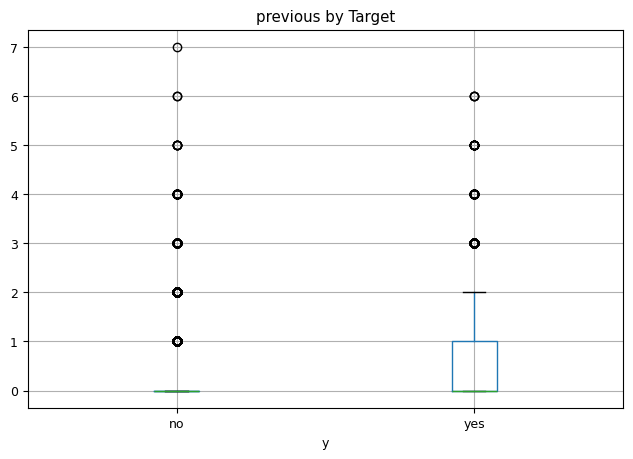

<Figure size 500x400 with 0 Axes>

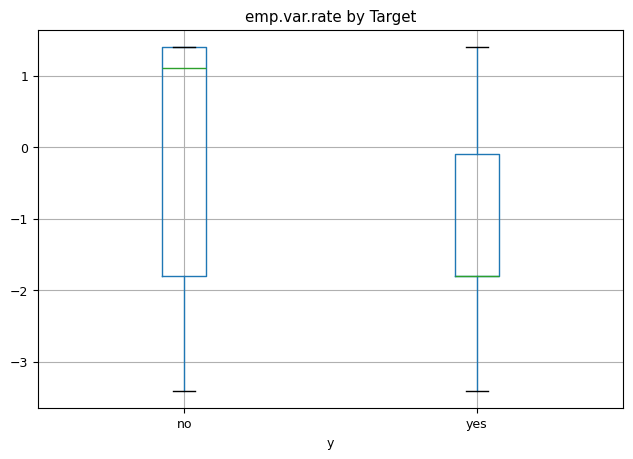

<Figure size 500x400 with 0 Axes>

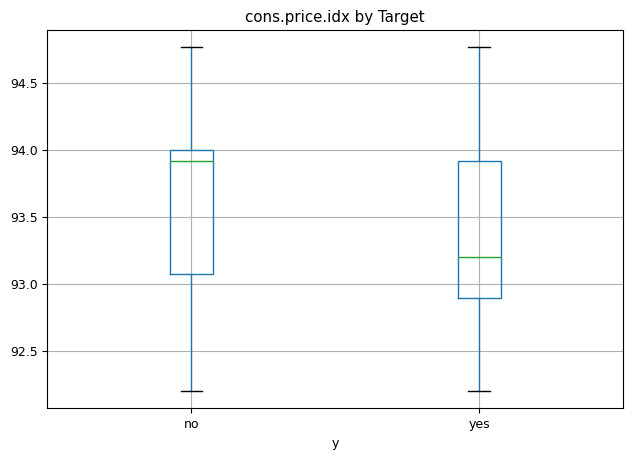

<Figure size 500x400 with 0 Axes>

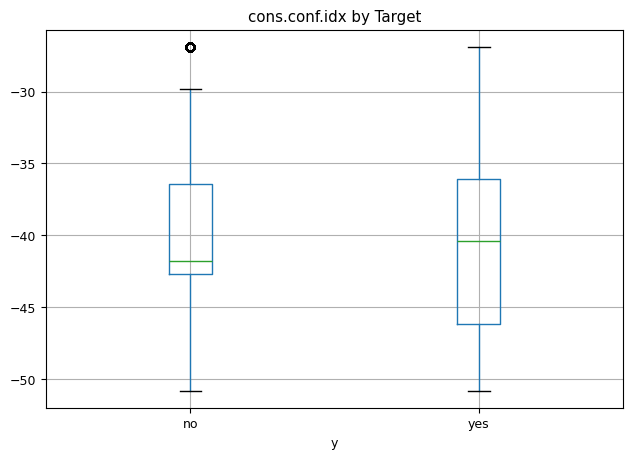

<Figure size 500x400 with 0 Axes>

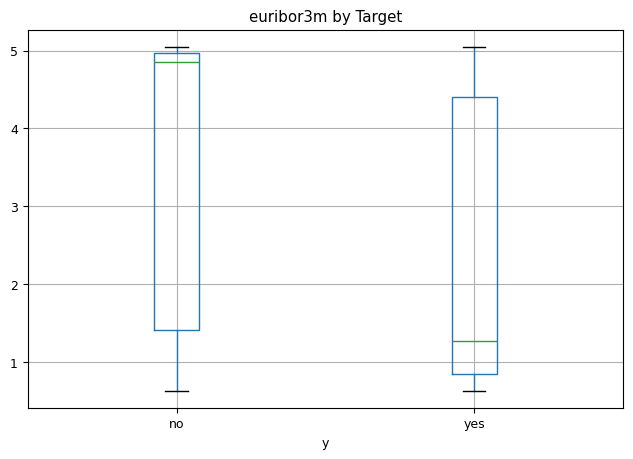

<Figure size 500x400 with 0 Axes>

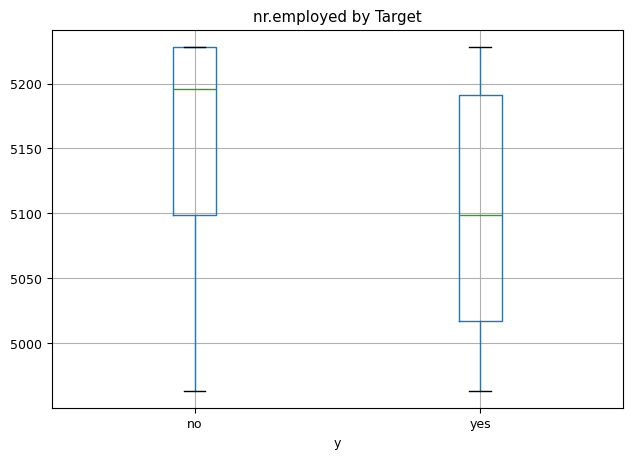

In [ ]:
for col in numeric_cols:

    plt.figure(figsize=(5, 4))

    df.boxplot(column=col, by=TARGET)

    plt.title(f"{col} by Target")
    plt.suptitle("")

    plt.tight_layout()

    plt.savefig(
        os.path.join(EDA_OUTPUT_DIR, f"boxplot_{col}.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    plt.close()

# 12) Unknown values

In [ ]:
unknown_summary = []

for col in categorical_cols:

    if "unknown" in df[col].astype(str).unique():

        share = (df[col] == "unknown").mean()

        unknown_summary.append({
            "column": col,
            "unknown_share": share,
        })

unknown_summary = pd.DataFrame(unknown_summary)

unknown_summary.to_csv(
    os.path.join(EDA_OUTPUT_DIR, "unknown_summary.csv"),
    index=False,
)

# 13) Binning

In [ ]:
for col in numeric_cols:

    tmp = df_target[[col, TARGET]].copy()

    tmp["bin"] = pd.qcut(
        tmp[col],
        q=10,
        duplicates="drop"
    )

    target_rate = (
        tmp.groupby("bin")[TARGET]
        .mean()
    )

    target_rate.to_csv(
        os.path.join(
            EDA_OUTPUT_DIR,
            f"numeric_target_rate_{col}.csv"
        )
    )

/tmp/ipykernel_475/1235182527.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("bin")[TARGET]
/tmp/ipykernel_475/1235182527.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("bin")[TARGET]
/tmp/ipykernel_475/1235182527.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("bin")[TARGET]
/tmp/ipykernel_475/1235182527.py:12: FutureWarning: The default of observed=False is deprecate

# 14) Duplicate rows


In [ ]:
duplicate_summary = pd.DataFrame({
    "metric": ["duplicate_rows"],
    "value": [df.duplicated().sum()]
})

duplicate_summary.to_csv(
    os.path.join(EDA_OUTPUT_DIR, "duplicate_summary.csv"),
    index=False,
)

# 15) Skewness numerical variables


In [ ]:
skewness_summary = pd.DataFrame({
    "feature": numeric_cols,
    "skewness": [
        df[col].skew()
        for col in numeric_cols
    ]
})

skewness_summary.to_csv(
    os.path.join(EDA_OUTPUT_DIR, "skewness_summary.csv"),
    index=False,
)

# 16) Save preview

In [ ]:

df.head(20).to_csv(
    os.path.join(EDA_OUTPUT_DIR, "data_preview.csv"),
    index=False,
)

print("\nEDA completed.")
print("Saved outputs to:", EDA_OUTPUT_DIR)


EDA completed.
Saved outputs to: /content/marketing_eda
